In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator
import seaborn as sns
from scipy import stats
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('figures/comparison_plots').mkdir(parents=True, exist_ok=True)
Path('results').mkdir(exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 9
sss  = 8
ssss = 6

matplotlib.rcParams['figure.figsize']       = (3.2, 2.8)
matplotlib.rcParams['figure.dpi']           = 600
matplotlib.rcParams['font.sans-serif']      = ['Arial']
matplotlib.rcParams['font.family']          = 'sans-serif'
matplotlib.rcParams['font.style']           = 'normal'
matplotlib.rcParams['font.weight']          = 'bold'
matplotlib.rcParams["axes.labelweight"]     = "bold"
matplotlib.rcParams['axes.titlesize']       = sss
matplotlib.rcParams['legend.fontsize']      = ss
matplotlib.rcParams['axes.labelsize']       = ss
matplotlib.rcParams['xtick.labelsize']      = ss
matplotlib.rcParams['ytick.labelsize']      = ss
matplotlib.rcParams['axes.linewidth']       = 0.6
matplotlib.rcParams['lines.linewidth']      = 1.0
matplotlib.rcParams['axes.grid']            = False

ref_line_size = 0.8

COLOR_MAP = {
    'train':    'tab:green',
    'test':     'tab:red',
    'edge':     'tab:orange',
    'interior': 'tab:blue',
}

# 模型列表与显示名称
MODELS_TO_COMPARE = ['ridge', 'svr', 'rf', 'xgb', 'dnn']
MODEL_NAME_MAP    = {'ridge': 'RR', 'svr': 'SVR', 'rf': 'RFR', 'xgb': 'XGB', 'dnn': 'DNN'}

models      = MODELS_TO_COMPARE
model_names = [MODEL_NAME_MAP[m] for m in models]




In [2]:
# =============================================================================
# 加载各模型结果数据，提取整体与分类性能指标
# =============================================================================

all_results_json       = {}
all_classification_csv = {}
missing_models         = []

for model in models:
    try:
        with open(f'models/{model}/{model}_results.json', 'r') as f:
            all_results_json[model] = json.load(f)
        all_classification_csv[model] = pd.read_csv(
            f'models/{model}/classification_scores.csv')
    except FileNotFoundError:
        missing_models.append(model)
            
        

for m in missing_models:
    models.remove(m)
    model_names.remove(MODEL_NAME_MAP[m])

# 整体性能
overall_summary = []
for model, name in zip(models, model_names):
    cv  = all_results_json[model]['cv_results']
    tr  = cv['train']
    te  = cv['test']
    overall_summary.append({
        'model_id':      model,
        'Model':         name,
        'Train_MAE':     tr['overall']['mae_mean'],
        'Train_MAE_std': tr['overall']['mae_std'],
        'Test_MAE':      te['overall']['mae_mean'],
        'Test_MAE_std':  te['overall']['mae_std'],
        'Train_RMSE':    tr['overall']['rmse_mean'],
        'Train_RMSE_std':tr['overall']['rmse_std'],
        'Test_RMSE':     te['overall']['rmse_mean'],
        'Test_RMSE_std': te['overall']['rmse_std'],
        'Train_R2':      tr['overall']['r2_mean'],
        'Train_R2_std':  tr['overall']['r2_std'],
        'Test_R2':       te['overall']['r2_mean'],
        'Test_R2_std':   te['overall']['r2_std'],
    })

df_overall     = pd.DataFrame(overall_summary)
df_ranked_mae  = df_overall.sort_values('Test_MAE')
df_ranked_rmse = df_overall.sort_values('Test_RMSE')

df_overall.to_csv('results/overall_performance_summary.csv', index=False)

# 边缘vs内部性能
edge_interior_summary = []
for model, name in zip(models, model_names):
    te = all_results_json[model]['cv_results']['test']
    edge_interior_summary.append({
        'model_id':        model,
        'Model':           name,
        'Edge_MAE':        te['edge']['mae_mean'],
        'Edge_MAE_std':    te['edge']['mae_std'],
        'Edge_RMSE':       te['edge']['rmse_mean'],
        'Edge_R2':         te['edge']['r2_mean'],
        'Edge_N':          te['edge']['n_samples_mean'],
        'Interior_MAE':    te['interior']['mae_mean'],
        'Interior_MAE_std':te['interior']['mae_std'],
        'Interior_RMSE':   te['interior']['rmse_mean'],
        'Interior_R2':     te['interior']['r2_mean'],
        'Interior_N':      te['interior']['n_samples_mean'],
    })

df_edge_interior = pd.DataFrame(edge_interior_summary)
df_edge_interior['Edge_Interior_Ratio'] = (
    df_edge_interior['Edge_MAE'] / df_edge_interior['Interior_MAE'])

df_edge_interior.to_csv('results/edge_interior_performance.csv', index=False)

# 按原子类型性能
atom_type_labels = ['O', 'C', 'Ti_inner', 'Ti_outer']
atom_type_summary = []
for model, name in zip(models, model_names):
    te = all_results_json[model]['cv_results']['test']
    for label in atom_type_labels:
        d = te['by_atom_type'][label]
        atom_type_summary.append({
            'model_id': model,
            'Model':    name,
            'Atom_Type':label,
            'MAE':      d['mae_mean'],
            'MAE_std':  d['mae_std'],
            'RMSE':     d['rmse_mean'],
            'R2':       d['r2_mean'],
            'N':        d['n_samples_mean'],
        })

df_atom_type = pd.DataFrame(atom_type_summary)
df_atom_type.to_csv('results/atom_type_performance.csv', index=False)

# 各折详细数据（用于统计检验）
fold_details = {}
for model in models:
    df_class   = all_classification_csv[model]
 
    folds      = ['1', '2', '3', '4', '5']
    df_folds   = df_class[df_class['fold'].astype(str).isin(folds)]
     
    overall_te = df_folds[(df_folds['dataset'] == 'test') &
                      (df_folds['category'] == 'overall') &
                      (df_folds['fold'].astype(str).isin(['1', '2', '3', '4', '5']))]
    
    fold_details[model] = {
        'test_mae':  overall_te['mae'].values,
        'test_rmse': overall_te['rmse'].values,
        'test_r2':   overall_te['r2'].values,
    }

# 配对t检验
p_value_matrix = np.ones((len(models), len(models)))
for i, model_i in enumerate(models):
    for j, model_j in enumerate(models):
        if i < j:
            _, p = stats.ttest_rel(
                fold_details[model_i]['test_mae'],
                fold_details[model_j]['test_mae']
            )
            p_value_matrix[i, j] = p
            p_value_matrix[j, i] = p



            

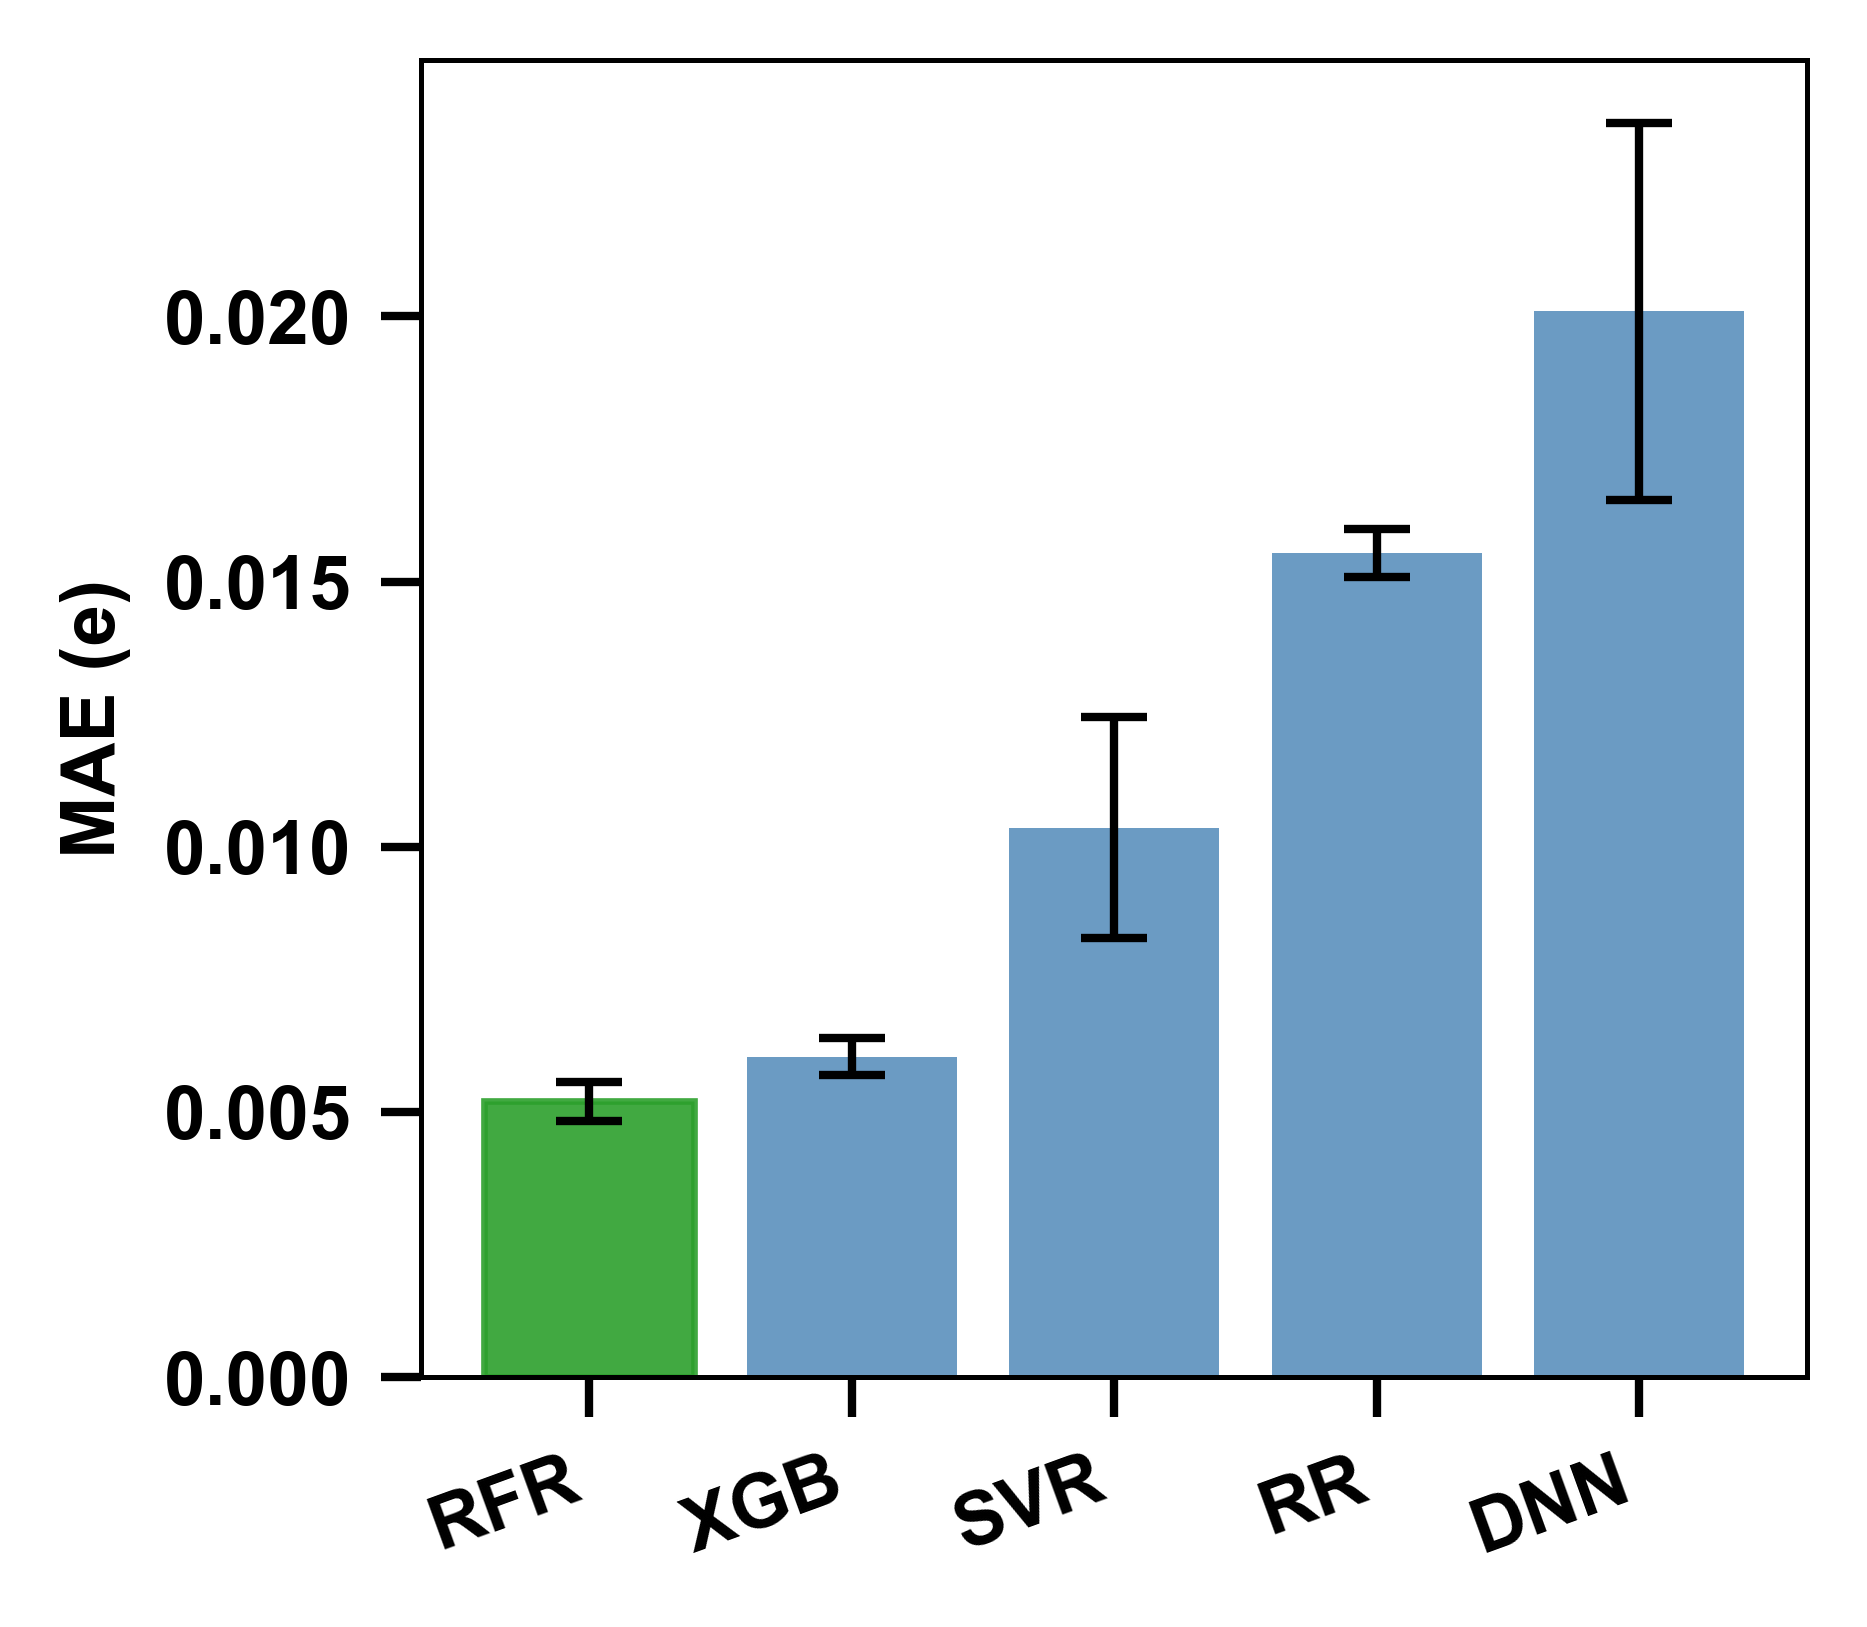

In [3]:
# =============================================================================
# 图1: 测试集MAE柱状图（论文用图）
# =============================================================================

fig, ax = plt.subplots(figsize=(3.2, 2.8))

df_plot = df_overall.sort_values('Test_MAE')
x       = np.arange(len(df_plot))
bars    = ax.bar(x, df_plot['Test_MAE'], yerr=df_plot['Test_MAE_std'],
                 capsize=4, alpha=0.8, color='steelblue',
                 error_kw={'linewidth': 1})
bars[0].set_color('tab:green')
bars[0].set_alpha(0.9)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['Model'], rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')

plt.tight_layout()
plt.savefig('figures/comparison_plots/01_overall_mae_test.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/comparison_plots/01_overall_mae_test.pdf', dpi=600, bbox_inches='tight')
plt.show()




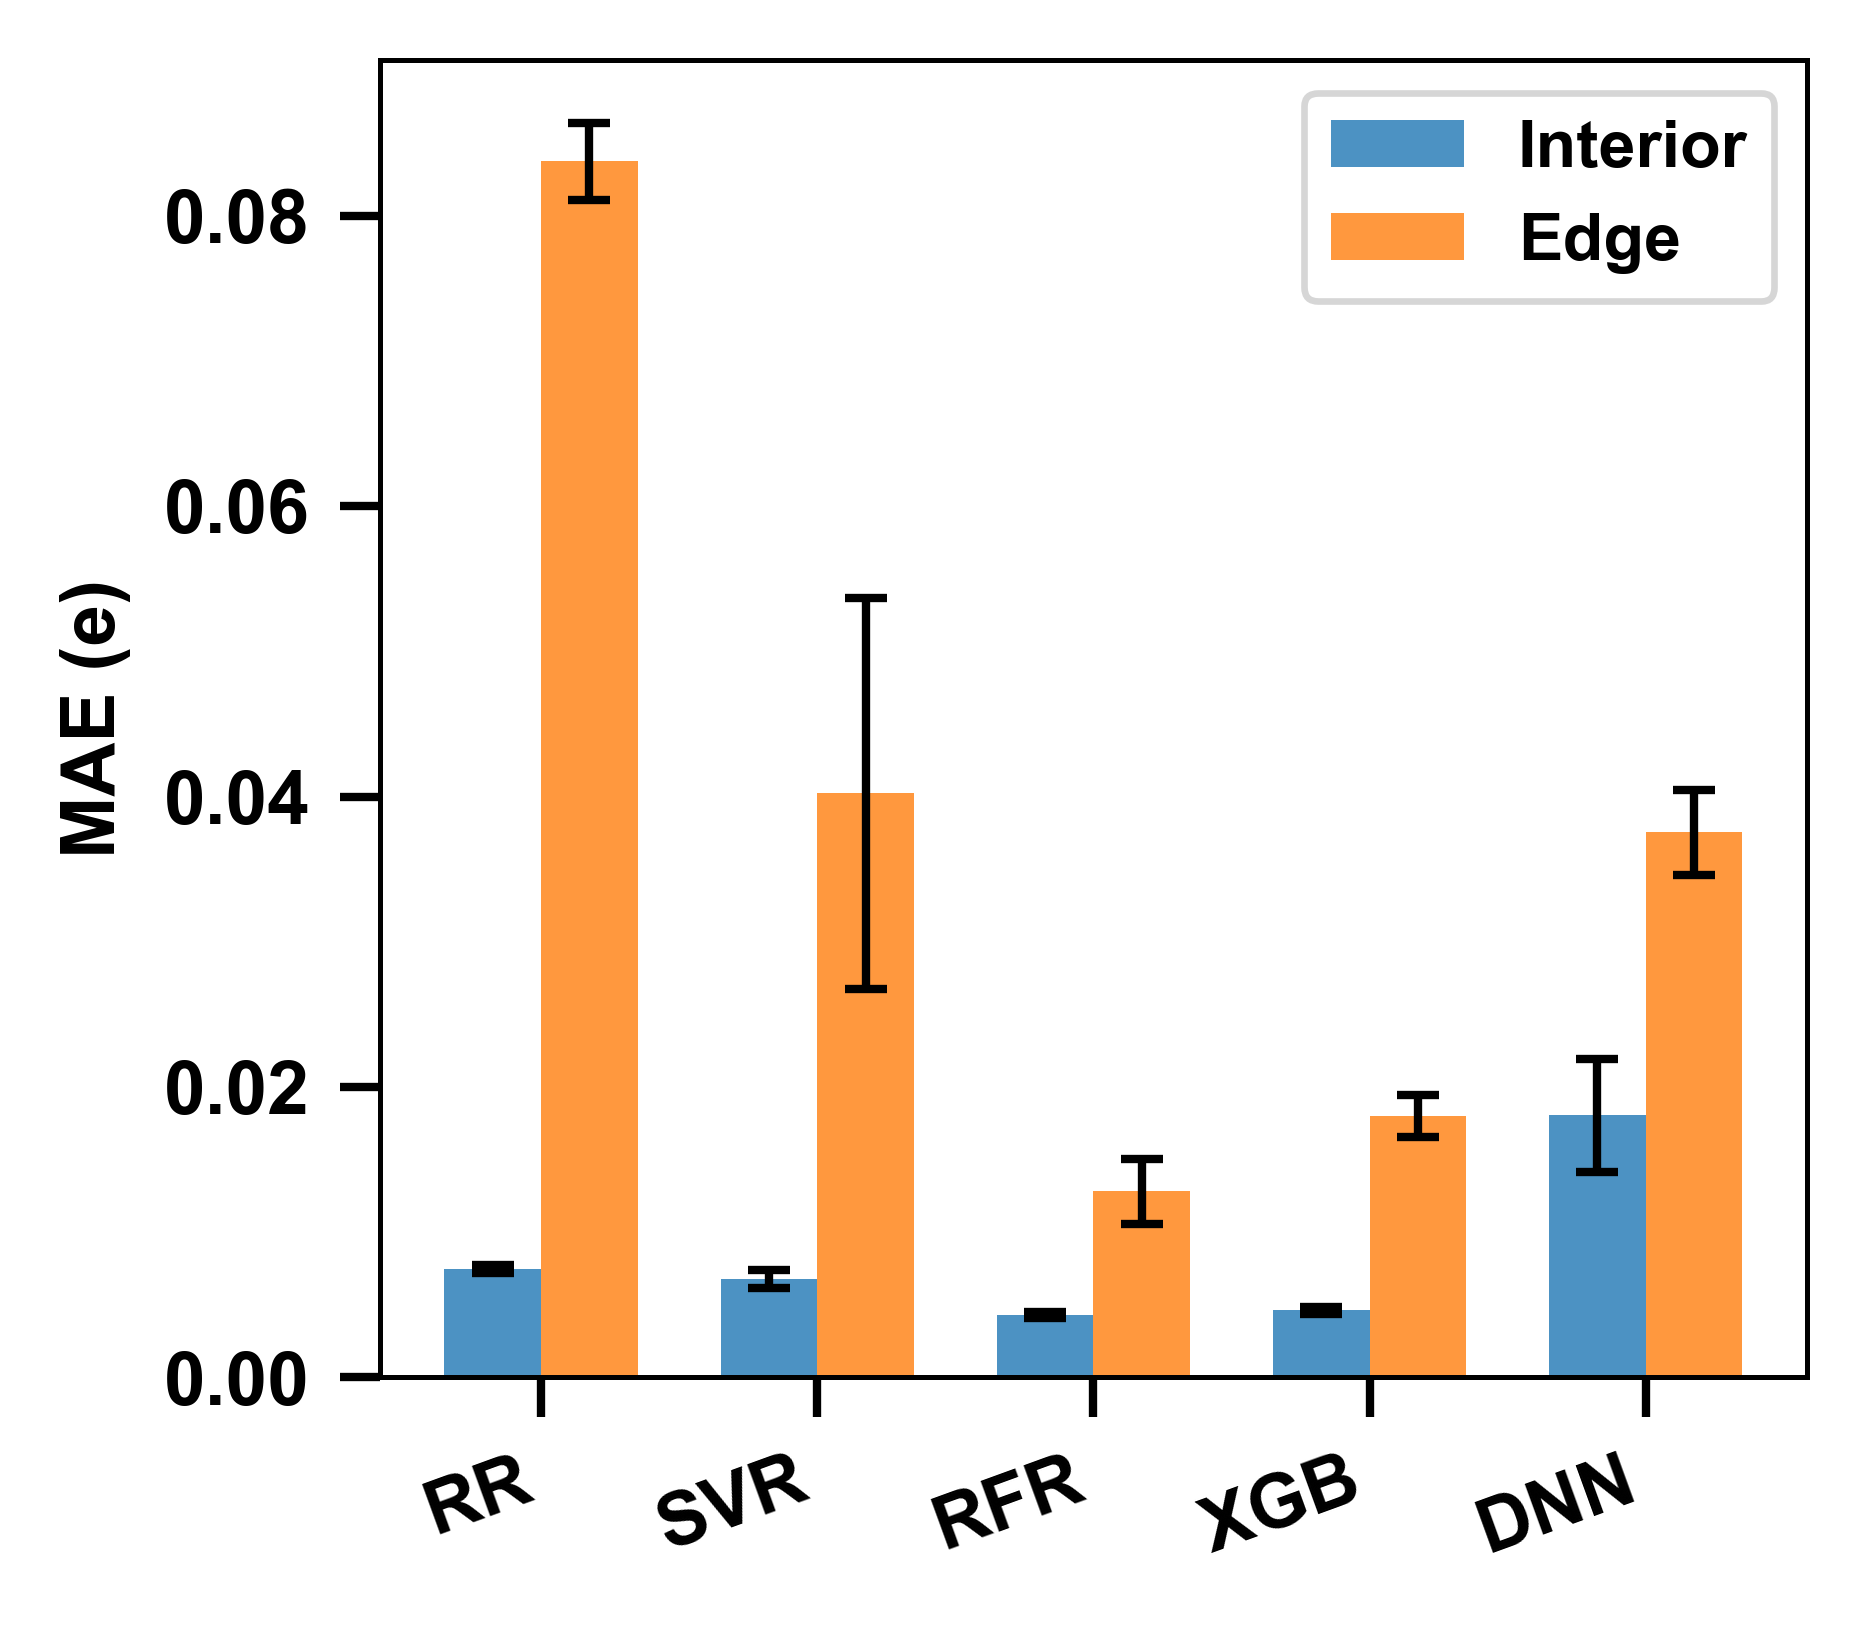

In [4]:
# =============================================================================
# 图2: 边缘vs内部原子MAE对比（论文用图）
# =============================================================================

fig, ax = plt.subplots(figsize=(3.2, 2.8))

x     = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, df_edge_interior['Interior_MAE'], width,
       yerr=df_edge_interior['Interior_MAE_std'],
       label='Interior', alpha=0.8, color=COLOR_MAP['interior'],
       capsize=2.5, error_kw={'linewidth': 1})

ax.bar(x + width/2, df_edge_interior['Edge_MAE'], width,
       yerr=df_edge_interior['Edge_MAE_std'],
       label='Edge', alpha=0.8, color=COLOR_MAP['edge'],
       capsize=2.5, error_kw={'linewidth': 1})

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', weight='bold')
ax.legend(fontsize=sss, frameon=True, loc='upper right')

plt.tight_layout()
plt.savefig('figures/comparison_plots/05_edge_vs_interior.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/comparison_plots/05_edge_vs_interior.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/comparison_plots/05_edge_vs_interior.tiff', dpi=600, bbox_inches='tight')
plt.show()




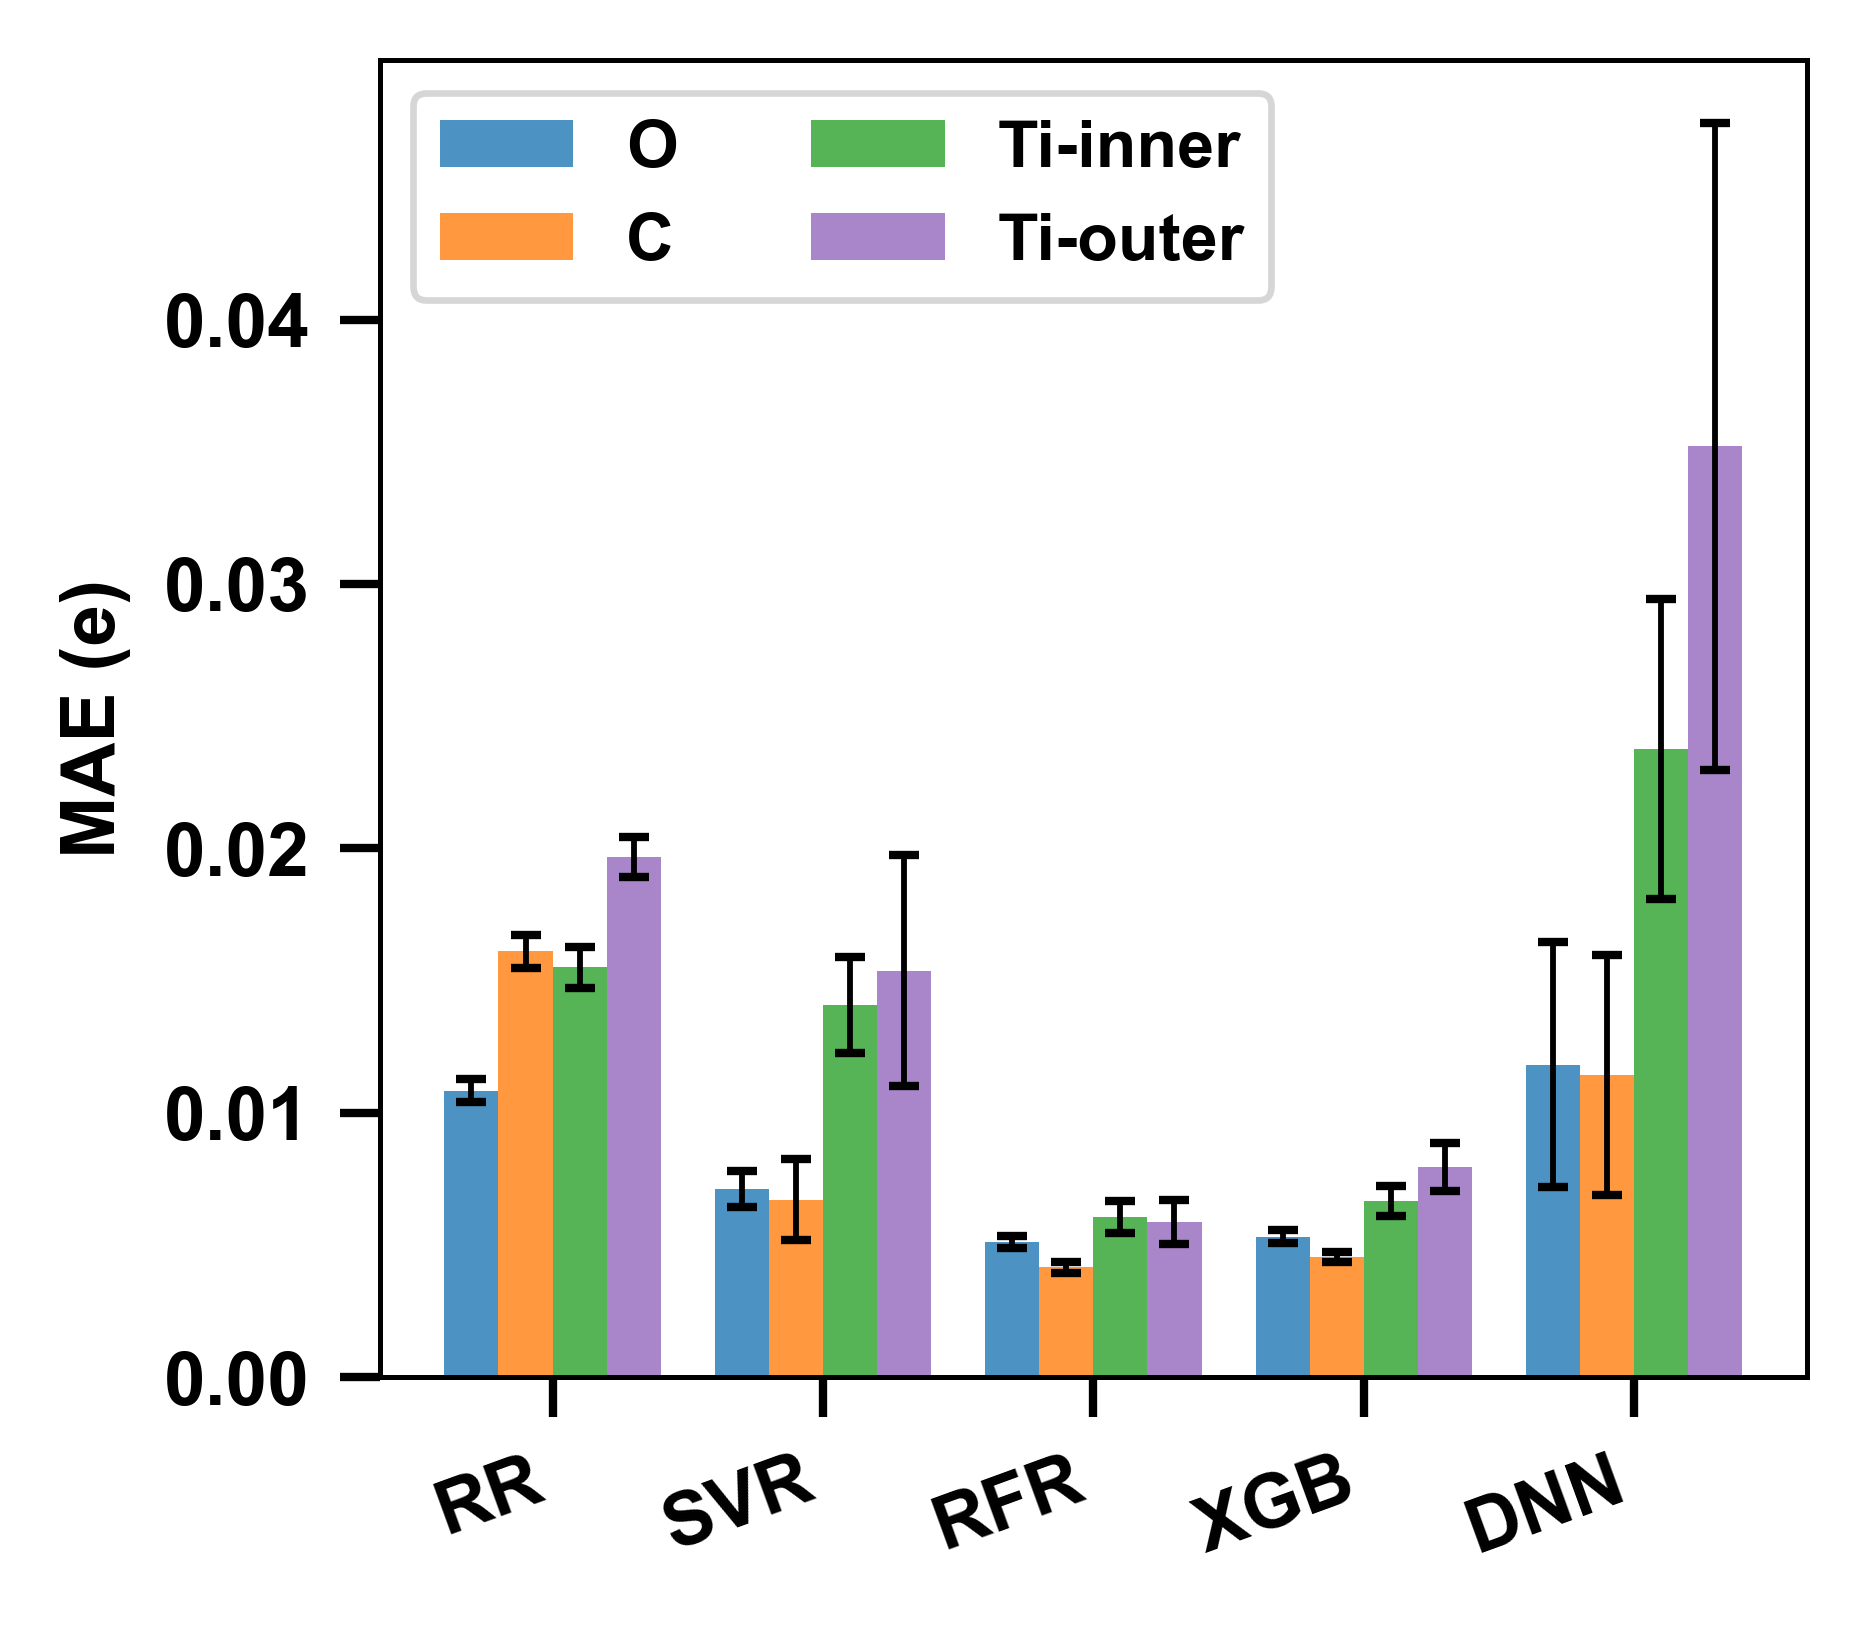

In [5]:
# =============================================================================
# 图3: 按原子类型MAE对比（论文用图）
# =============================================================================

fig, ax = plt.subplots(figsize=(3.2, 2.8))

atom_type_labels_display = ['O', 'C', 'Ti-inner', 'Ti-outer']
atom_colors              = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
n_types                  = len(atom_type_labels)
x                        = np.arange(len(models))
width                    = 0.20

for idx, (label, display_label, color) in enumerate(
        zip(atom_type_labels, atom_type_labels_display, atom_colors)):
    maes = []
    stds = []
    for model in models:
        row = df_atom_type[(df_atom_type['model_id'] == model) &
                           (df_atom_type['Atom_Type'] == label)]
        maes.append(row['MAE'].values[0])
        stds.append(row['MAE_std'].values[0])

    offset = width * (idx - n_types / 2 + 0.5)
    ax.bar(x + offset, maes, width, yerr=stds,
           label=display_label, alpha=0.8, color=color,
           capsize=1.8, error_kw={'linewidth': 0.7})

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.legend(fontsize=sss, frameon=True, loc='upper left', ncol=2)
ax.yaxis.set_major_locator(MultipleLocator(0.01))

plt.tight_layout()
plt.savefig('figures/comparison_plots/06_by_atom_type.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/comparison_plots/06_by_atom_type.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figures/comparison_plots/06_by_atom_type.tiff', dpi=600, bbox_inches='tight')
plt.show()